In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_excel("../data/Telco_customer_churn.xlsx")

In [6]:
df.shape

(7043, 33)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

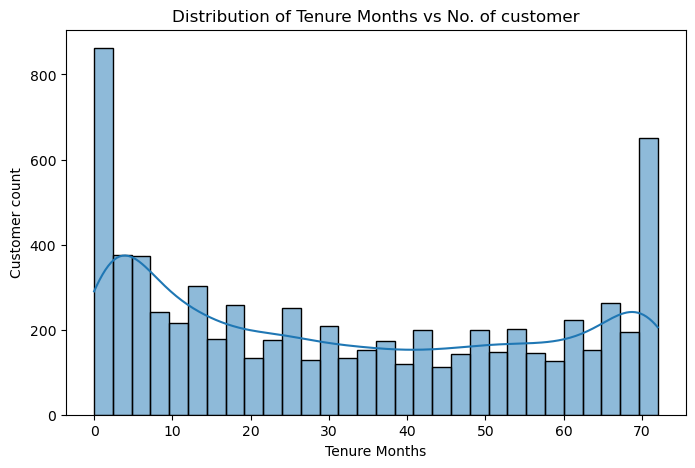

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs No. of customer')
plt.show()

#### Graphic Insights: Distribution of Tenure Months
**What the Plot Shows**: The customer base is heavily concentrated at the extreme ends of the spectrum—either brand-new customers (0–5 months) or highly veteran customers (65–72 months).

**Business Takeaway**: The first year is the "danger zone." If a customer survives their first 12 months with the company, their loyalty increases dramatically, and they tend to become long-term users.

In [10]:
df['Tenure Months'].max()

72

In [11]:
df['Tenure Months'].min()

0

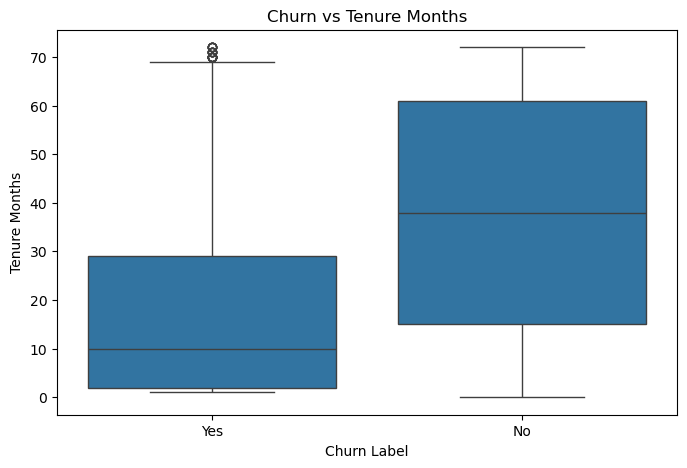

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y='Tenure Months', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months')
plt.show()

#### Churn vs Tenure Months
**What the Plot Shows**: There is a massive structural difference in tenure between groups. Customers who leave (Churn = Yes) have a significantly lower median tenure compared to customers who stay.

**Business Takeaway**: Churn is heavily tied to customer onboarding and early-stage satisfaction. Retention strategies must target subscribers in their first few months.

In [13]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

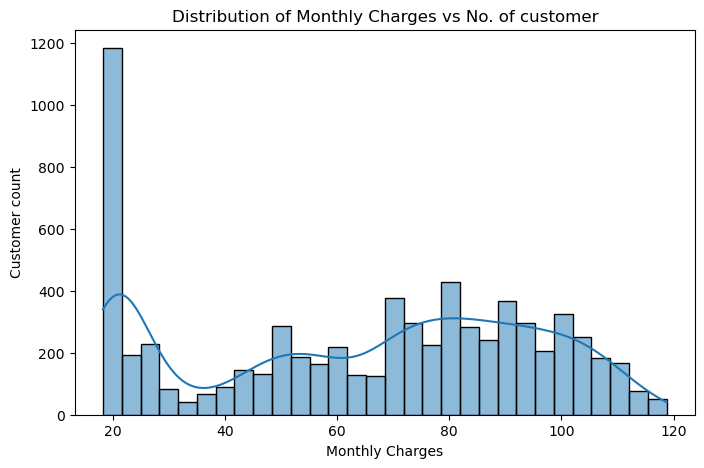

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Monthly Charges vs No. of customer')
plt.show()

#### Distribution of Monthly Charges
**What the Plot Shows**: There is a huge spike of customers paying very low rates ($18–$25), followed by a steady distribution of users paying higher subscription fees between 70 and 100.

**Business Takeaway**: The company relies heavily on two primary customer types: a massive volume of basic users and a consistent block of high-tier premium service subscribers.

In [15]:
df['Monthly Charges'].max()

118.75

In [16]:
df['Monthly Charges'].min()

18.25

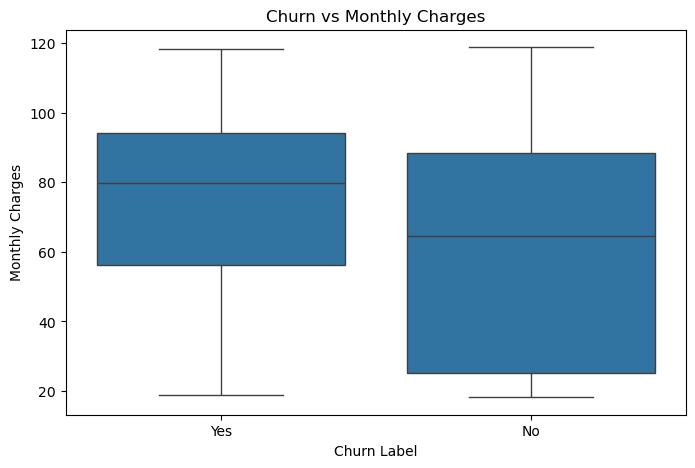

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y='Monthly Charges', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges')
plt.show()

#### Churn vs Monthly Charges
**What the Plot Shows**: The median monthly charge for customers who churned is noticeably higher (near $80) than the median charge for customers who stayed (near $65).

**Business Takeaway**: Price sensitivity is a major driver of churn. Customers paying higher monthly fees are significantly more likely to drop their service.

In [18]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    56.15
0.50    79.65
0.75    94.20
Name: Monthly Charges, dtype: float64

In [19]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    25.100
0.50    64.425
0.75    88.400
Name: Monthly Charges, dtype: float64

In [20]:
df['Monthly Charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [21]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    35.50
0.50    70.35
0.75    89.85
Name: Monthly Charges, dtype: float64

In [22]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [23]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

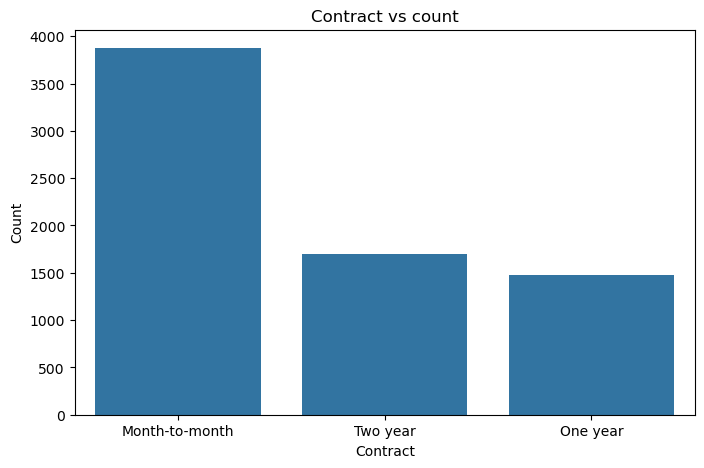

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', data=df)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs count')
plt.show()

#### Distribution of Contract Types
**What the Plot Shows**: The vast majority of the company's subscriber base is on a short-term 'Month-to-month' contract, followed by smaller, roughly equal shares of customers on 'Two year' and 'One year' agreements.

**Business Takeaway**: Because more than half of the customer database has no long-term contractual commitment, the company's revenue stream is highly volatile and exposed to immediate turnover risks.

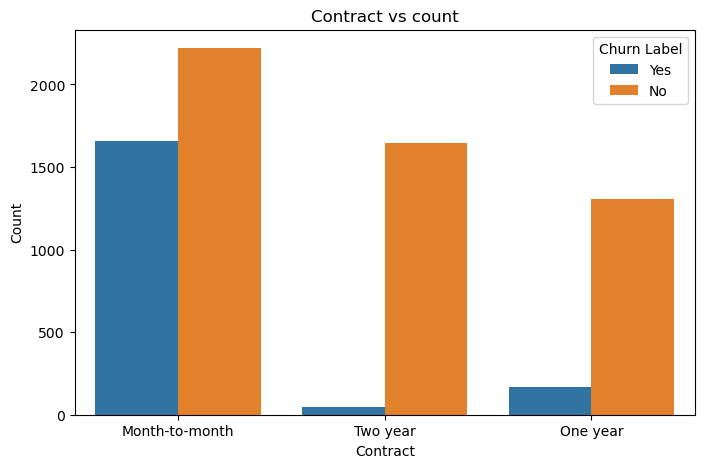

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs count')
plt.show()

#### Contract Type vs Churn Count
**What the Plot Shows**: The vast majority of churn occurs among customers on 'Month-to-month' contracts. Conversely, churn is practically non-existent for customers locked into 'One year' or 'Two year' agreements.

**Business Takeaway**: Month-to-month contracts are highly unstable. Shifting customers from month-to-month plans over to long-term commitments is the single most effective way to reduce churn.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [27]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

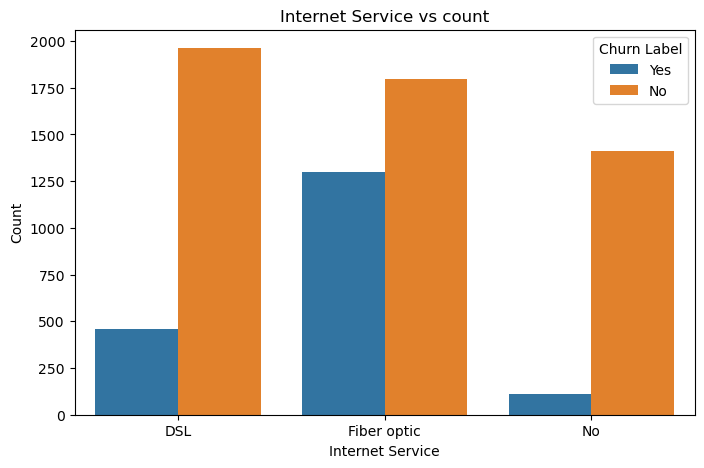

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.title('Internet Service vs count')
plt.show()

#### Internet Service vs Churn Count
**What the Plot Shows**: Customers with 'Fiber optic' internet experience an incredibly high rate of churn compared to 'DSL' users or those with no internet service at all.

**Business Takeaway**: This points to a potential systemic issue. The fiber optic service might be suffering from technical instability, poor performance, or aggressive pricing structures.

In [29]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

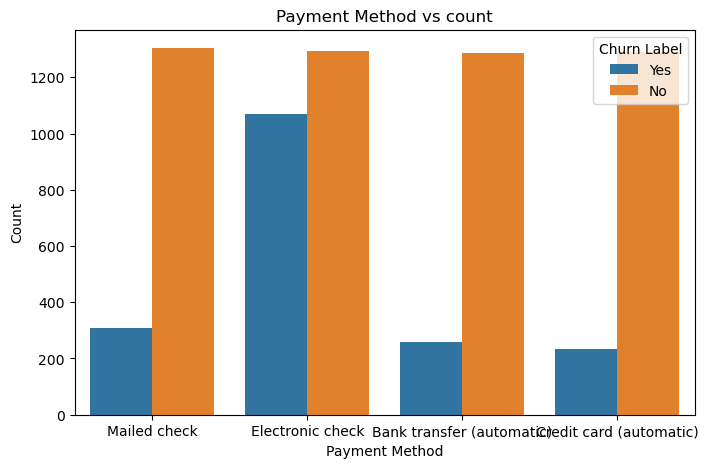

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method vs count')
plt.show()

#### Payment Method vs Churn Count
**What the Plot Shows**: Customers using 'Electronic check' churn at a significantly higher rate than any other payment demographic, including automated options like bank transfers or credit cards.

**Business Takeaway**: Non-automated billing introduces monthly friction. Automated billing pathways create seamless, passive customer retention.

In [31]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

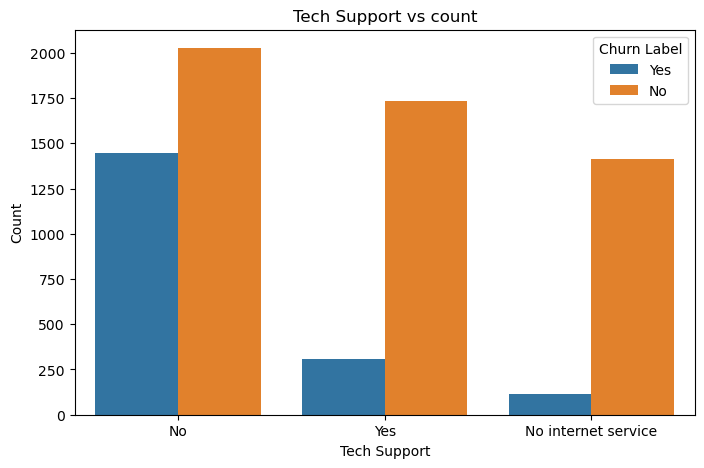

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support vs count')
plt.show()

#### Tech Support vs Churn Count
**What the Plot Shows**: Customers who do not have 'Tech Support' account for the highest volume of churned users. Those with active tech support show much higher loyalty.

**Business Takeaway**: Providing easily accessible troubleshooting resources keeps customers happy. Offering tech support as a free incentive during the fragile first 6 months could drastically reduce customer drop-off.

In [33]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()

In [34]:
avg_tenure

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [36]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix=df[numerical_cols].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [37]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'])
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [38]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319
